Animal Verification Pipeline
Enter your text describing the animal: cow
Upload an image file:


Saving Papilio_machaon_Mitterbach_01.jpg to Papilio_machaon_Mitterbach_01.jpg
Classifier weights already present.
NER tokenizer dir already exists.
NER weights already present.


Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracted animals from text: {'cow'}
Predicted from image: butterfly
Match? False
Does the text describe the image? -> No


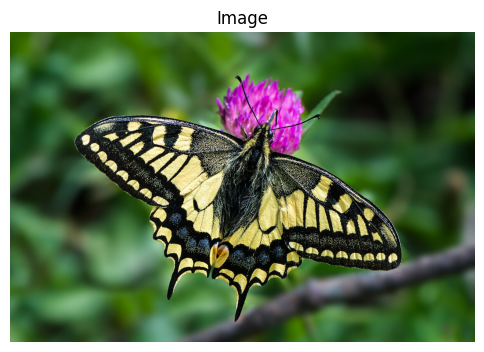

In [4]:
import os
import matplotlib.pyplot as plt
import torch
from torchvision import models, transforms
from PIL import Image
from transformers import RobertaTokenizerFast, RobertaForTokenClassification
import gdown
from google.colab import files

# Google Drive IDs with weights and tokenizer
CLASSIFIER_DRIVE_ID = "1Yz_DvxRTs4y0_6gBUsG1F4ODwXZgYH1w"
NER_TOKENIZER_DRIVE_ID = "1Rs1c5DtyYB17zgcBK_MAFYsfAF1bklHs"
NER_WEIGHTS_DRIVE_ID = "1KkjluZVzaBcO6SmKtXjwuN8i-P_VyhSm"

# Local files
CLASSIFIER_WEIGHTS = "classifier_resnet18.pth"
NER_TOKENIZER_DIR = "ner_tokenizer"
NER_WEIGHTS = "ner_model_weights.pth"

# NER mappings
tag2id = {"O": 0, "B-ANIMAL": 1, "I-ANIMAL": 2}
id2tag = {v: k for k, v in tag2id.items()}

# class names
class_names_en = ["dog", "horse", "elephant", "butterfly", "chicken", "cat", "cow", "sheep", "spider", "squirrel"]

def download_from_drive(file_id: str, dest: str):
    url = f"https://drive.google.com/uc?id={file_id}"
    gdown.download(url, dest, quiet=False)

def ensure_models_present():
    # classifier weights
    if not os.path.exists(CLASSIFIER_WEIGHTS):
        print("Downloading classifier weights...")
        download_from_drive(CLASSIFIER_DRIVE_ID, CLASSIFIER_WEIGHTS)
    else:
        print("Classifier weights already present.")

    # NER tokenizer zip
    if not os.path.isdir(NER_TOKENIZER_DIR):
        print("Downloading NER tokenizer...")
        download_from_drive(NER_TOKENIZER_DRIVE_ID, NER_TOKENIZER_DIR + ".zip")
        import zipfile
        with zipfile.ZipFile(NER_TOKENIZER_DIR + ".zip", 'r') as zf:
            zf.extractall(NER_TOKENIZER_DIR)
        os.remove(NER_TOKENIZER_DIR + ".zip")
    else:
        print("NER tokenizer dir already exists.")

    # NER weights
    if not os.path.exists(NER_WEIGHTS):
        print("Downloading NER model weights...")
        download_from_drive(NER_WEIGHTS_DRIVE_ID, NER_WEIGHTS)
    else:
        print("NER weights already present.")

#Models

def load_ner_model_and_tokenizer():
    tokenizer = RobertaTokenizerFast.from_pretrained(NER_TOKENIZER_DIR)
    model = RobertaForTokenClassification.from_pretrained("roberta-base", num_labels=len(tag2id))
    state_dict = torch.load(NER_WEIGHTS, map_location=torch.device("cpu"))
    model.load_state_dict(state_dict)
    model.eval()
    return model, tokenizer

def load_classifier_model():
    model = models.resnet18(pretrained=False)
    model.fc = torch.nn.Linear(model.fc.in_features, len(class_names_en))
    state_dict = torch.load(CLASSIFIER_WEIGHTS, map_location=torch.device("cpu"))
    model.load_state_dict(state_dict)
    model.eval()
    return model

def animal_verification_pipeline(text: str, image_path: str) -> bool:
    ensure_models_present()

    # load models
    ner_model, ner_tokenizer = load_ner_model_and_tokenizer()
    classifier_model = load_classifier_model()

    # NER: extract animal mentions in text
    tokens = text.split()
    encoding = ner_tokenizer(tokens,
                             is_split_into_words=True,
                             return_tensors="pt",
                             add_special_tokens=True,
                             truncation=True,
                             padding="max_length",
                             max_length=64)
    word_ids = encoding.word_ids(batch_index=0)

    with torch.no_grad():
        outputs = ner_model(**encoding)
    logits = outputs.logits
    preds = torch.argmax(logits, dim=-1).squeeze().tolist()

    extracted_animals = set()
    previous_word_idx = None
    for i, widx in enumerate(word_ids):
        if widx is None:
            continue
        if widx != previous_word_idx:
            tag = id2tag[preds[i]]
            if tag.startswith("B-") or tag.startswith("I-"):
                extracted_animals.add(tokens[widx].lower())
        previous_word_idx = widx

    if not extracted_animals:
        print("No animals found in text.")
        return False

    # image classification
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0)

    with torch.no_grad():
        output = classifier_model(input_tensor)
        pred_idx = torch.argmax(output, dim=1).item()
    predicted_animal = class_names_en[pred_idx]

    # result
    result = predicted_animal.lower() in extracted_animals

    print("Extracted animals from text:", extracted_animals)
    print("Predicted from image:", predicted_animal)
    print("Match?", result)

    return result

# DEMO

if __name__ == "__main__":
    print("Animal Verification Pipeline")
    user_text = input("Enter your text describing the animal: ")
    print("Upload an image file:")
    uploaded = files.upload()
    image_path = list(uploaded.keys())[0]

    ok = animal_verification_pipeline(user_text, image_path)

    print("Does the text describe the image? ->", "Yes" if ok else "No")

    img = Image.open(image_path)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Image")
    plt.show()
